# Model Alignment on the Categorization Task (Levering 2020)

This notebook measures how well LLMs and VLMs align with human decisions in a category learning experiment from [marcelbinz/Psych-101](https://huggingface.co/datasets/marcelbinz/Psych-101).

**Two conditions from Levering (2020):**
- **NLS** (`exp1.csv`, 126 participants): Non-linearly separable rule — no single feature dimension predicts category W vs N
- **LS** (`exp2.csv`, 102 participants): Linearly separable rule — shape alone determines category

**Three analyses:**
1. **Condition comparison** — mean NLL per model on NLS vs LS, averaged across N participants with SE error bars
2. **Contamination check** — standard vs relabeled prompts (W→P, N→Q + code permutation); large NLL increase flags potential memorization
3. **VLM input variants** — text-only vs image-only vs image+text stimulus presentation

### Imports & API Client

In [1]:
import io
import base64
import os
import re

from openai import OpenAI
from dotenv import load_dotenv
from datasets import load_dataset
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec

In [2]:
load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)

### Configuration

In [3]:
# ── Quick-test flag ───────────────────────────────────────────────────────────
# When True: 2 participants, 30 trials each, first model only.
# Set False for full production run.
QUICK_TEST = True

# ── Conditions ────────────────────────────────────────────────────────────────
# Both experiments use category labels W and N in the Psych-101 dataset.
# (The spec referenced Z/R/H labels which do not appear in the actual data;
#  we relabel W→P and N→Q for both conditions as the contamination check.)
CONDITION_MAP = {
    "levering2020revisiting/exp1.csv": "NLS",
    "levering2020revisiting/exp2.csv": "LS",
}

# ── Participant sampling ───────────────────────────────────────────────────────
N_PARTICIPANTS  = 2 if QUICK_TEST else 5
PARTICIPANT_SEED = 42
N_TRIALS_CAP    = 30 if QUICK_TEST else None   # None = all trials

# ── Token sets ────────────────────────────────────────────────────────────────
CATEGORY_TOKENS_STANDARD  = {"W", "N"}
CATEGORY_TOKENS_RELABELED = {"P", "Q"}
RELABEL_MAP   = {"W": "P", "N": "Q"}
RATING_TOKENS = {str(i) for i in range(1, 10)}

# All 8 stimulus codes (3-digit binary strings over {1,2})
ALL_STIMULUS_CODES = ["111", "112", "121", "122", "211", "212", "221", "222"]

# ── Model lists ───────────────────────────────────────────────────────────────
_ALL_LLM_MODELS = [
    "Llama-3.3-70B-Instruct",
    "gemini-3-flash-preview",
]
_ALL_VLM_MODELS = [
    "gemini-2.5-pro",
    "claude-sonnet-4-5",
]

LLM_MODELS = _ALL_LLM_MODELS[:1] if QUICK_TEST else _ALL_LLM_MODELS
VLM_MODELS = _ALL_VLM_MODELS[:1] if QUICK_TEST else _ALL_VLM_MODELS

print(f"QUICK_TEST={QUICK_TEST} | participants={N_PARTICIPANTS} | trials_cap={N_TRIALS_CAP}")
print(f"LLM models: {LLM_MODELS}")
print(f"VLM models: {VLM_MODELS}")

QUICK_TEST=True | participants=2 | trials_cap=30
LLM models: ['Llama-3.3-70B-Instruct']
VLM models: ['gemini-2.5-pro']


### Load Dataset — Both Conditions

In [4]:
dataset = load_dataset("marcelbinz/Psych-101")
df = pd.DataFrame(dataset["train"])

condition_dfs = {}
for exp_name, condition in CONDITION_MAP.items():
    condition_dfs[exp_name] = df[df["experiment"] == exp_name].reset_index(drop=True)
    print(f"{condition} ({exp_name}): {len(condition_dfs[exp_name])} participants")

NLS (levering2020revisiting/exp1.csv): 126 participants
LS (levering2020revisiting/exp2.csv): 102 participants


In [5]:
# Preview participant sampling (deterministic via seed)
rng_preview = np.random.default_rng(PARTICIPANT_SEED)
for exp_name, condition in CONDITION_MAP.items():
    n = len(condition_dfs[exp_name])
    idxs = rng_preview.choice(n, size=N_PARTICIPANTS, replace=False).tolist()
    print(f"{condition}: sampled participant indices = {idxs}")

NLS: sampled participant indices = [11, 97]
LS: sampled participant indices = [44, 101]


### Helper Functions

- `extract_steps` — unchanged from original; parses `<<DECISION>>` markers
- `compute_nll` — unchanged; computes NLL of a human decision from logprobs
- `relabel_text` — applies contamination-check relabeling: W→P, N→Q + code permutation
- `render_stimulus` — copied from `simulation.ipynb`; renders a 3-digit code as a base64 PNG

In [6]:
# ── extract_steps ─────────────────────────────────────────────────────────────
def extract_steps(text):
    pattern = r"<<(.*?)>>"
    matches = list(re.finditer(pattern, text))
    steps = []
    prev_end = 0
    for m in matches:
        start, end = m.span()
        decision = m.group(1).strip()
        prefix = text[prev_end:start]
        if decision.lower() == "nan":
            prev_end = end
            continue
        steps.append({"prefix": prefix, "decision": decision})
        prev_end = end
    return steps


# ── compute_nll ───────────────────────────────────────────────────────────────
def compute_nll(logprobs, human_decision, valid_tokens):
    valid_entries = {
        entry.token.strip().upper(): entry.logprob
        for entry in logprobs
        if entry.token.strip().upper() in valid_tokens
    }
    if human_decision not in valid_entries:
        return np.nan
    log_probs = np.array(list(valid_entries.values()))
    probs = np.exp(log_probs)
    probs /= probs.sum()
    human_idx = list(valid_entries.keys()).index(human_decision)
    return -np.log(probs[human_idx])


# ── relabel_text ──────────────────────────────────────────────────────────────
def relabel_text(text):
    """Contamination-check relabeling:
    1. Permute 3-digit stimulus codes: swap positions 0 and 2 (XYZ -> ZYX).
       e.g. '122' -> '221', '211' -> '112'. All 8 codes permute within the set.
    2. Replace category labels W->P and N->Q (word-boundary safe).
    """
    def _permute(m):
        c = m.group(0)
        return c[2] + c[1] + c[0]

    text = re.sub(r'\b[12]{3}\b', _permute, text)
    text = re.sub(r'\bW\b', 'P', text)
    text = re.sub(r'\bN\b', 'Q', text)
    return text


# ── render_stimulus ───────────────────────────────────────────────────────────
def render_stimulus(code, dpi=80):
    """Render a 3-digit stimulus code as a base64-encoded PNG image.
    digit 1 — shape  (1=square, 2=triangle)
    digit 2 — size   (1=large, 2=small)
    digit 3 — shade  (1=black, 2=white)
    Copied from simulation.ipynb.
    """
    shape = int(code[0])
    size  = int(code[1])
    shade = int(code[2])

    fig, ax = plt.subplots(figsize=(2, 2))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal"); ax.axis("off")
    fig.patch.set_facecolor("#c8c8c8")

    sz = 0.55 if size == 1 else 0.32
    fc = "black" if shade == 1 else "white"
    cx, cy = 0.5, 0.5

    if shape == 1:
        patch = patches.Rectangle(
            (cx - sz/2, cy - sz/2), sz, sz,
            facecolor=fc, edgecolor="black", linewidth=2
        )
    else:
        h   = sz * np.sqrt(3) / 2
        pts = np.array([[cx, cy + 2*h/3],
                        [cx - sz/2, cy - h/3],
                        [cx + sz/2, cy - h/3]])
        patch = patches.Polygon(pts, closed=True,
                                facecolor=fc, edgecolor="black", linewidth=2)
    ax.add_patch(patch)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight", pad_inches=0.05)
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

In [7]:
# Pre-render all 8 stimulus images once (used by VLM image variants)
STIMULUS_IMAGES = {code: render_stimulus(code) for code in ALL_STIMULUS_CODES}
print(f"Pre-rendered {len(STIMULUS_IMAGES)} stimulus images.")

Pre-rendered 8 stimulus images.


### Alignment Loop

`run_alignment` runs one model on one participant's steps and returns per-trial `(human_decisions, logprobs, correct)`.

**`input_variant`** (VLMs only):
- `"text_only"` — plain text prompt, same as LLM path
- `"image_only"` — current trial's stimulus replaced with a PNG; prior history stays as text
- `"image_and_text"` — same as image_only but code string also included as caption alongside image

In [8]:
def run_alignment(model, steps, valid_tokens, input_variant="text_only"):
    """Run alignment for one model on one participant's step sequence.

    Args:
        model:         LiteLLM model string
        steps:         output of extract_steps() — may be standard or relabeled
        valid_tokens:  set of valid category token strings (e.g. {"W","N"} or {"P","Q"})
        input_variant: "text_only" | "image_only" | "image_and_text"

    Returns:
        human_decisions: list[str]  — category decisions only (ratings excluded)
        logprobs_list:   list       — top_logprobs per trial, or None if unsupported
        correct_list:    list[bool] — whether model's top token matched human
    """
    model_context    = ""
    human_decisions  = []
    logprobs_list    = []
    correct_list     = []
    cue = f"(Respond with only {' or '.join(sorted(valid_tokens))})"

    for step in steps:
        human_decision = step["decision"]
        prefix         = step["prefix"]

        # Rating steps: update context silently, skip API call
        if human_decision in RATING_TOKENS:
            model_context += prefix + f"<<{human_decision}>>"
            continue

        full_text = model_context + prefix

        # ── Build message ──────────────────────────────────────────────────
        if input_variant == "text_only":
            messages = [{"role": "user", "content": full_text + f"<<{cue}"}]
        else:
            # Find last stimulus code in the accumulated text
            img_matches = list(re.finditer(r'image (\d{3})', full_text))
            if img_matches:
                m    = img_matches[-1]
                code = m.group(1)
                img_b64 = STIMULUS_IMAGES.get(code, STIMULUS_IMAGES[ALL_STIMULUS_CODES[0]])
                before  = full_text[:m.start()] + "image "   # keep "image " prefix
                after   = full_text[m.end():]                # ", press " etc.

                if input_variant == "image_only":
                    content = [
                        {"type": "text",      "text": before},
                        {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
                        {"type": "text",      "text": after + f"<<{cue}"},
                    ]
                else:  # image_and_text
                    content = [
                        {"type": "text",      "text": before},
                        {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
                        {"type": "text",      "text": f" (code: {code})" + after + f"<<{cue}"},
                    ]
                messages = [{"role": "user", "content": content}]
            else:
                # No image code found — fall back to text_only
                messages = [{"role": "user", "content": full_text + f"<<{cue}"}]

        model_context += prefix + f"<<{human_decision}>>"

        # ── Query model ────────────────────────────────────────────────────
        lp        = None
        top_token = None
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=messages,
                logprobs=True,
                top_logprobs=5,
            )
            lp        = resp.choices[0].logprobs.content[0].top_logprobs
            top_token = lp[0].token.strip().upper()
        except Exception as e:
            err = str(e).lower()
            if any(x in err for x in ["logprob", "400", "unsupported", "not supported"]):
                # Logprobs unsupported — greedy fallback (no NLL, accuracy only)
                try:
                    resp = client.chat.completions.create(model=model, messages=messages)
                    raw = resp.choices[0].message.content.strip().upper()
                    top_token = next((t for t in sorted(valid_tokens) if t in raw), None)
                except Exception as e2:
                    print(f"    [error] {e2}")
            else:
                print(f"    [error] {e}")

        human_decisions.append(human_decision)
        logprobs_list.append(lp)
        correct_list.append(top_token == human_decision if top_token else None)

    return human_decisions, logprobs_list, correct_list

In [ ]:
# ── Main loop ─────────────────────────────────────────────────────────────────
# raw_results key: (model, condition, prompt_variant, input_variant)
#   prompt_variant : "standard" | "relabeled"
#   input_variant  : "text_only" | "image_only" | "image_and_text"
# raw_results value: {"nll": [[per-trial NLL] × N_PARTICIPANTS],
#                     "correct": [[bool] × N_PARTICIPANTS]}

raw_results = {}
rng = np.random.default_rng(PARTICIPANT_SEED)

for exp_name, condition in CONDITION_MAP.items():
    exp_df = condition_dfs[exp_name]
    pidxs  = rng.choice(len(exp_df), size=N_PARTICIPANTS, replace=False).tolist()
    print(f"\n{'='*60}")
    print(f"Condition: {condition}  |  participants: {pidxs}")
    print(f"{'='*60}")

    for pidx in pidxs:
        full_text     = exp_df["text"].iloc[pidx]
        steps_std = extract_steps(full_text)
        steps_rel = extract_steps(relabel_text(full_text))
        if N_TRIALS_CAP is not None:
            steps_std = steps_std[:N_TRIALS_CAP]
            steps_rel = steps_rel[:N_TRIALS_CAP]

        # ── LLMs: standard + relabeled, text_only ─────────────────────────
        for model in LLM_MODELS:
            for pv, (cur_steps, vtokens) in [
                ("standard",  (steps_std, CATEGORY_TOKENS_STANDARD)),
                ("relabeled", (steps_rel, CATEGORY_TOKENS_RELABELED)),
            ]:
                key = (model, condition, pv, "text_only")
                print(f"  {model} | {condition} | {pv} | text_only  (participant {pidx})")
                hd, lp, correct = run_alignment(model, cur_steps, vtokens, "text_only")
                nll = [compute_nll(l, h, vtokens) if l is not None else np.nan
                       for h, l in zip(hd, lp)]
                raw_results.setdefault(key, {"nll": [], "correct": []})
                raw_results[key]["nll"].append(nll)
                raw_results[key]["correct"].append(correct)

        # ── VLMs: standard (3 input variants) + relabeled text_only ───────
        for model in VLM_MODELS:
            for iv in ["text_only", "image_only", "image_and_text"]:
                key = (model, condition, "standard", iv)
                print(f"  {model} | {condition} | standard | {iv}  (participant {pidx})")
                hd, lp, correct = run_alignment(model, steps_std, CATEGORY_TOKENS_STANDARD, iv)
                nll = [compute_nll(l, h, CATEGORY_TOKENS_STANDARD) if l is not None else np.nan
                       for h, l in zip(hd, lp)]
                raw_results.setdefault(key, {"nll": [], "correct": []})
                raw_results[key]["nll"].append(nll)
                raw_results[key]["correct"].append(correct)

            # Relabeled text_only for contamination check
            key = (model, condition, "relabeled", "text_only")
            print(f"  {model} | {condition} | relabeled | text_only  (participant {pidx})")
            hd, lp, correct = run_alignment(model, steps_rel, CATEGORY_TOKENS_RELABELED, "text_only")
            nll = [compute_nll(l, h, CATEGORY_TOKENS_RELABELED) if l is not None else np.nan
                   for h, l in zip(hd, lp)]
            raw_results.setdefault(key, {"nll": [], "correct": []})
            raw_results[key]["nll"].append(nll)
            raw_results[key]["correct"].append(correct)

print("\nDone. Keys collected:", len(raw_results))


Condition: NLS  |  participants: [11, 97]
  Llama-3.3-70B-Instruct | NLS | standard | text_only  (participant 11)
  Llama-3.3-70B-Instruct | NLS | relabeled | text_only  (participant 11)
  gemini-2.5-pro | NLS | standard | text_only  (participant 11)


### Compute NLL & Top-1 Accuracy

In [ ]:
# Aggregate per-participant NLL lists into mean ± SE
metrics = {}

for key, data in raw_results.items():
    p_nll = [np.nanmean(trials) for trials in data["nll"]]
    p_acc = [np.nanmean([c for c in trials if c is not None])
             for trials in data["correct"]]

    metrics[key] = {
        "mean_nll":        np.mean(p_nll),
        "se_nll":          np.std(p_nll) / np.sqrt(len(p_nll)),
        "mean_acc":        np.mean(p_acc),
        "participant_nlls": p_nll,
    }

    model, cond, pv, iv = key
    print(f"{model} | {cond} | {pv} | {iv}:  "
          f"NLL={metrics[key]['mean_nll']:.3f} ± {metrics[key]['se_nll']:.3f}  "
          f"acc={metrics[key]['mean_acc']:.1%}")

Llama-3.3-70B-Instruct | NLS | standard | text_only:  NLL=nan ± nan  acc=nan%
Llama-3.3-70B-Instruct | NLS | relabeled | text_only:  NLL=nan ± nan  acc=nan%
gemini-2.5-pro | NLS | standard | text_only:  NLL=nan ± nan  acc=nan%
gemini-2.5-pro | NLS | standard | image_only:  NLL=nan ± nan  acc=nan%
gemini-2.5-pro | NLS | standard | image_and_text:  NLL=nan ± nan  acc=nan%
gemini-2.5-pro | NLS | relabeled | text_only:  NLL=nan ± nan  acc=nan%
Llama-3.3-70B-Instruct | LS | standard | text_only:  NLL=nan ± nan  acc=nan%
Llama-3.3-70B-Instruct | LS | relabeled | text_only:  NLL=nan ± nan  acc=nan%
gemini-2.5-pro | LS | standard | text_only:  NLL=nan ± nan  acc=nan%
gemini-2.5-pro | LS | standard | image_only:  NLL=nan ± nan  acc=nan%
gemini-2.5-pro | LS | standard | image_and_text:  NLL=nan ± nan  acc=nan%
gemini-2.5-pro | LS | relabeled | text_only:  NLL=nan ± nan  acc=nan%


/var/folders/6v/c7_fd_w12v9dpwpb8r6jn6180000gn/T/ipykernel_96259/3186246981.py:5: RuntimeWarning: Mean of empty slice
  p_nll = [np.nanmean(trials) for trials in data["nll"]]
/var/folders/6v/c7_fd_w12v9dpwpb8r6jn6180000gn/T/ipykernel_96259/3186246981.py:6: RuntimeWarning: Mean of empty slice
  p_acc = [np.nanmean([c for c in trials if c is not None])


### Visualize Results

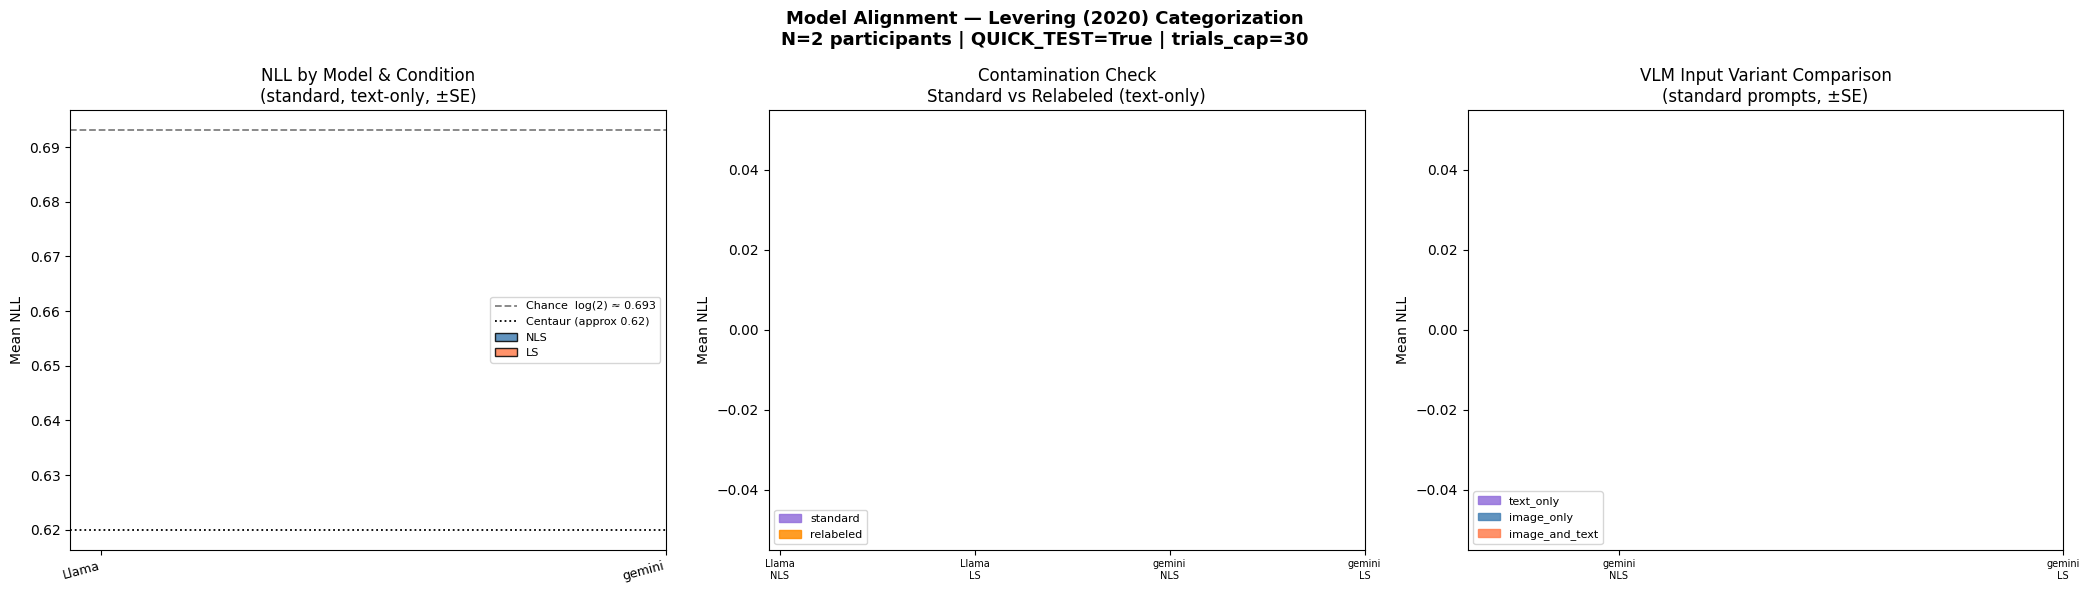

In [ ]:
import math

LOG2        = math.log(2)   # chance NLL for binary classification ≈ 0.693
CENTAUR_NLL = 0.62          # placeholder — update with actual Centaur value

COND_COLORS    = {"NLS": "steelblue",    "LS": "coral"}
VARIANT_COLORS = {"standard": "mediumpurple", "relabeled": "darkorange"}
INPUT_COLORS   = {"text_only": "mediumpurple", "image_only": "steelblue", "image_and_text": "coral"}
CONDITIONS     = ["NLS", "LS"]
NLL_FLAG_DELTA = 0.15   # annotate ⚠ if relabeled NLL exceeds standard by this amount

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# ── Panel 1: Mean NLL per model grouped by condition ──────────────────────────
ax1 = axes[0]
p1_models = list(dict.fromkeys(
    k[0] for k in metrics if k[2] == "standard" and k[3] == "text_only"
))
x     = np.arange(len(p1_models))
width = 0.35

for i, cond in enumerate(CONDITIONS):
    means = [metrics.get((m, cond, "standard", "text_only"), {}).get("mean_nll", np.nan) for m in p1_models]
    ses   = [metrics.get((m, cond, "standard", "text_only"), {}).get("se_nll",   0)       for m in p1_models]
    ax1.bar(x + (i - 0.5) * width, means, width,
            label=cond, color=COND_COLORS[cond], alpha=0.85, edgecolor="black",
            yerr=ses, capsize=4)

ax1.axhline(LOG2,        color="gray",  linestyle="--", linewidth=1.3, label=f"Chance  log(2) ≈ {LOG2:.3f}")
ax1.axhline(CENTAUR_NLL, color="black", linestyle=":",  linewidth=1.3, label=f"Centaur (approx {CENTAUR_NLL})")
ax1.set_xticks(x)
ax1.set_xticklabels([m.split("-")[0] for m in p1_models], rotation=15, ha="right", fontsize=9)
ax1.set_ylabel("Mean NLL")
ax1.set_title("NLL by Model & Condition\n(standard, text-only, ±SE)")
ax1.legend(fontsize=8)

# ── Panel 2: Standard vs relabeled contamination check ────────────────────────
ax2 = axes[1]
p2_models = list(dict.fromkeys(k[0] for k in metrics if k[3] == "text_only"))

pos   = 0
xticks, xlabels = [], []
for model in p2_models:
    for cond in CONDITIONS:
        std_nll = metrics.get((model, cond, "standard",  "text_only"), {}).get("mean_nll", np.nan)
        rel_nll = metrics.get((model, cond, "relabeled", "text_only"), {}).get("mean_nll", np.nan)
        for vi, (pv, val) in enumerate([("standard", std_nll), ("relabeled", rel_nll)]):
            xp = pos + vi * width - width / 2
            ax2.bar(xp, val, width, color=VARIANT_COLORS[pv], alpha=0.85, edgecolor="black")
            if pv == "relabeled" and not (np.isnan(std_nll) or np.isnan(rel_nll)):
                if rel_nll - std_nll > NLL_FLAG_DELTA:
                    ax2.text(xp, val + 0.02, "⚠", ha="center", va="bottom", fontsize=11)
        xticks.append(pos)
        xlabels.append(f"{model.split('-')[0]}\n{cond}")
        pos += 1

ax2.set_xticks(xticks)
ax2.set_xticklabels(xlabels, fontsize=7)
ax2.set_ylabel("Mean NLL")
ax2.set_title("Contamination Check\nStandard vs Relabeled (text-only)")
handles2 = [plt.Rectangle((0,0),1,1, color=VARIANT_COLORS[v], alpha=0.85) for v in ["standard","relabeled"]]
ax2.legend(handles2, ["standard", "relabeled"], fontsize=8)

# ── Panel 3: VLM input variant comparison ─────────────────────────────────────
ax3 = axes[2]
input_variants = ["text_only", "image_only", "image_and_text"]

if VLM_MODELS and any(k[0] in VLM_MODELS for k in metrics):
    bar_w   = 0.22
    group_w = len(input_variants) * bar_w + 0.15
    pos = 0
    xticks3, xlabels3 = [], []

    for model in VLM_MODELS:
        for cond in CONDITIONS:
            for vi, iv in enumerate(input_variants):
                val = metrics.get((model, cond, "standard", iv), {}).get("mean_nll", np.nan)
                se  = metrics.get((model, cond, "standard", iv), {}).get("se_nll",   0)
                xp  = pos * group_w + vi * bar_w
                ax3.bar(xp, val, bar_w, color=INPUT_COLORS[iv], alpha=0.85,
                        edgecolor="black", yerr=se, capsize=3)
            xticks3.append(pos * group_w + bar_w)
            xlabels3.append(f"{model.split('-')[0]}\n{cond}")
            pos += 1

    ax3.set_xticks(xticks3)
    ax3.set_xticklabels(xlabels3, fontsize=7)
    handles3 = [plt.Rectangle((0,0),1,1, color=INPUT_COLORS[iv], alpha=0.85) for iv in input_variants]
    ax3.legend(handles3, input_variants, fontsize=8)
else:
    ax3.text(0.5, 0.5, "No VLM results\n(run VLM_MODELS)", ha="center", va="center",
             transform=ax3.transAxes, fontsize=11, color="gray")

ax3.set_ylabel("Mean NLL")
ax3.set_title("VLM Input Variant Comparison\n(standard prompts, ±SE)")

plt.suptitle(
    f"Model Alignment — Levering (2020) Categorization\n"
    f"N={N_PARTICIPANTS} participants | QUICK_TEST={QUICK_TEST} | trials_cap={N_TRIALS_CAP}",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("levering_alignment_comparison.png", dpi=150, bbox_inches="tight")
plt.show()